 # EfficientNet-B0 Autoencoder – ISIC 2018 MEL vs NV

 Binary classification: **MEL** (melanoma) vs **NV** (melanocytic nevi) using the ISIC 2018 Task 3 training set.

 | Detail | Value |
 |---|---|
 | Backbone | EfficientNet-B0 (ImageNet-pretrained) |
 | Input size | 224 × 224 (EfficientNet-B0 default) |
 | Train/Val split | 80 / 20, `random_split` seeded at 42 |
 | Class imbalance | `WeightedRandomSampler` on train split (NV greatly outnumbers MEL) |
 | Val metric | VGG19 Perceptual Loss |
 | Checkpointing | Per-epoch, auto-resume from latest `epoch_*.pth` |

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sys
import glob

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from datasets import ISIC2018Dataset, TransformDataset
from vgg_loss import VGGLoss

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.10.0+cu128 | CUDA available: True


In [ ]:
# ── Parameters (edit here) ────────────────────────────────────────────────────
DATASET_DIR    = "./dataset/ISIC_2018/ISIC2018_Task3_Training_Input"
LABELS_CSV     = "./dataset/ISIC_2018/ISIC2018_Task3_Training_GroundTruth.csv"
IMAGE_SIZE     = 224          # EfficientNet-B0 default
BATCH_SIZE     = 8
NUM_WORKERS    = 4
VAL_SPLIT      = 0.2          # fraction held out for validation
LEARNING_RATE  = 1e-4         # lower LR appropriate for fine-tuning
NUM_EPOCHS     = 20
CHECKPOINT_DIR = "./checkpoints/efficientnet_nv_mel_ae_vgg"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_NAMES    = ["NV", "MEL"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Using device  : {DEVICE}")
print(f"Image size    : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")

Using device  : cuda
Image size    : 224 x 224
Checkpoint dir: /home/tejass_iitp/capstone/checkpoints/efficientnet_nv_mel_ae_vgg


In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Train: augmentations to reduce over-fitting on the small MEL class.
# Val  : deterministic centre-crop only.
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    # TODO: maybe add rotation by random angle as well? (also change in classifer)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transform pipelines defined.")

Transform pipelines defined.


In [ ]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────
# Base dataset with transform=None so it returns raw PIL images.
# TransformDataset wraps each split with its own augmentation pipeline.

full_dataset = ISIC2018Dataset(
    root_dir       = DATASET_DIR,
    transform      = None,
    labels_csv     = LABELS_CSV,
    include_labels = LABEL_NAMES,
)

print(f"Total labeled samples (NV+MEL): {len(full_dataset)}")

# ── Train / Val split ─────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_sub, val_sub = random_split(
    full_dataset, [n_train, n_val], generator=generator
)

train_dataset = TransformDataset(train_sub, train_transform)
val_dataset   = TransformDataset(val_sub,   val_transform)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")

# ── Collect raw one-hot labels for WeightedRandomSampler (no image I/O) ──────
# label_map rows are [NV, MEL]; binary label = argmax
all_labels = [
    int(full_dataset.label_map.loc[
        os.path.splitext(os.path.basename(p))[0]
    ].values.argmax())
    for p in full_dataset.image_paths
]
class_counts = np.bincount(all_labels)
print(f"Class counts  : NV={class_counts[0]:,}  MEL={class_counts[1]:,}")

# ── WeightedRandomSampler on train split only ─────────────────────────────────
train_labels   = [all_labels[i] for i in train_sub.indices]
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in train_labels]
train_sampler  = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val   batches/epoch : {len(val_loader)}")

Found 10015 valid JPEG images in './dataset/ISIC_2018/ISIC2018_Task3_Training_Input'
Total labeled samples (NV+MEL): 10015
Train samples : 8,012
Val   samples : 2,003
Class counts  : NV=8,902  MEL=1,113
Train batches/epoch : 1002
Val   batches/epoch : 251


Batch shape : torch.Size([8, 3, 224, 224])
Labels (raw): [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 0.0], [1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [0.0, 0.0]]


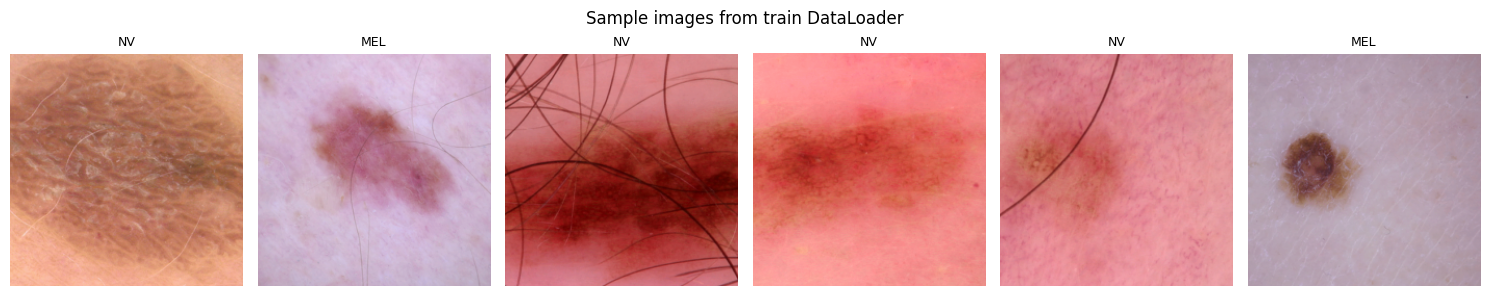

In [ ]:
# ── Sanity check: visualise a batch ──────────────────────────────────────────
sample_imgs, sample_labels = next(iter(train_loader))
print("Batch shape :", sample_imgs.shape)
print("Labels (raw):", sample_labels[:8].tolist())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    cls = sample_labels[i].argmax().item()
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample images from train DataLoader", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Model – EfficientNet-B0 Autoencoder ───────────────────────────────────────
#
# EfficientNet-B0 feature extractor layout (model.features)
# The decoder reconstructs the images from the 1280x7x7 feature maps.

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

FREEZE_UP_TO = 0
for i in range(FREEZE_UP_TO):
    for param in backbone.features[i].parameters():
        param.requires_grad = False

class EfficientNetAutoencoder(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder.features
        # encoder output: (B, 1280, 7, 7) for 224x224 input
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1280, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            # Linear output to match normalized inputs
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.decoder(features)

model = EfficientNetAutoencoder(backbone).to(DEVICE)

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters   : {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Frozen parameters   : 0
Trainable parameters: 17,251,775


In [ ]:
criterion = VGGLoss().to(DEVICE)

# Only pass parameters that require gradients to the optimiser
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# ── History buffers ───────────────────────────────────────────────────────────
train_losses     = []
val_losses       = []
start_epoch      = 1

# ── Resume from latest checkpoint if one exists ───────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
if existing:
    latest = existing[-1]
    ckpt   = torch.load(latest, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    scheduler.load_state_dict(ckpt["sched_state"])
    start_epoch      = ckpt["epoch"] + 1
    train_losses     = ckpt.get("train_losses", [])
    val_losses       = ckpt.get("val_losses", [])
    print(f"Resumed from '{latest}' (epoch {ckpt['epoch']} of {NUM_EPOCHS})")
else:
    print("No checkpoint found – starting from scratch.")

if start_epoch > NUM_EPOCHS:
    print(f"Training already complete ({NUM_EPOCHS} epochs done). Nothing to do.")

No checkpoint found – starting from scratch.


In [ ]:
# ── Training loop (checkpoints every epoch) ───────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    total        = 0

    pbar = tqdm(train_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] train", leave=False)
    for imgs, labels_onehot in pbar:
        imgs          = imgs.to(DEVICE, non_blocking=True)

        reconstructions = model(imgs)
        loss   = criterion(reconstructions, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total        += imgs.size(0)
        pbar.set_postfix(loss=f"{running_loss / total:.4f}")

    scheduler.step()

    train_loss = running_loss / total
    train_losses.append(train_loss)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    val_total        = 0

    with torch.no_grad():
        for imgs, labels_onehot in tqdm(val_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] val  ", leave=False):
            imgs          = imgs.to(DEVICE, non_blocking=True)

            reconstructions = model(imgs)
            loss   = criterion(reconstructions, imgs)
            val_running_loss += loss.item() * imgs.size(0)
            val_total        += imgs.size(0)

    val_loss = val_running_loss / val_total
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch:>3}/{NUM_EPOCHS}]  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  "
        f"lr={scheduler.get_last_lr()[0]:.2e}"
    )

    # ── Save per-epoch checkpoint ──────────────────────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
    torch.save({
        "epoch"       : epoch,
        "model_state" : model.state_dict(),
        "optim_state" : optimizer.state_dict(),
        "sched_state" : scheduler.state_dict(),
        "config": {
            "image_size"    : IMAGE_SIZE,
            "freeze_up_to"  : FREEZE_UP_TO,
            "val_split"     : VAL_SPLIT,
        },
        "train_losses"     : train_losses,
        "val_losses"       : val_losses,
    }, ckpt_path)
    print(f"  └─ Checkpoint saved: {ckpt_path}")

print("\nTraining complete.")

Epoch [  1/20]  train_loss=5.3920  val_loss=4.5494  lr=9.94e-05
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_001.pth


Epoch [  2/20]  train_loss=4.9143  val_loss=4.3429  lr=9.76e-05
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_002.pth


Epoch [  3/20]  train_loss=4.6969  val_loss=4.2038  lr=9.46e-05
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_003.pth


Epoch [  4/20]  train_loss=4.6083  val_loss=4.0859  lr=9.05e-05
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_004.pth


Epoch [  5/20]  train_loss=4.4717  val_loss=3.9280  lr=8.55e-05
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_005.pth


...

Epoch [ 16/20]  train_loss=3.5443  val_loss=3.1337  lr=1.05e-05
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_016.pth


Epoch [ 17/20]  train_loss=3.5347  val_loss=3.1191  lr=6.40e-06
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_017.pth


Epoch [ 18/20]  train_loss=3.5272  val_loss=3.1210  lr=3.42e-06
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_018.pth


Epoch [ 19/20]  train_loss=3.4936  val_loss=3.1108  lr=1.61e-06
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_019.pth


Epoch [ 20/20]  train_loss=3.5011  val_loss=3.1069  lr=1.00e-06
  └─ Checkpoint saved: ./checkpoints/efficientnet_nv_mel_ae_vgg/epoch_020.pth

Training complete.


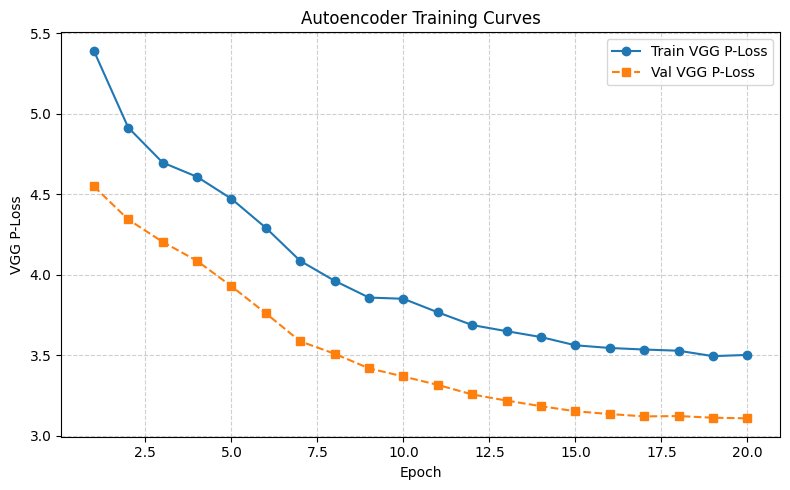

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
n_recorded = len(train_losses)
epochs_x   = range(1, n_recorded + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_x, train_losses, marker="o", linewidth=1.5, label="Train VGG P-Loss")
plt.plot(epochs_x, val_losses,   marker="s", linewidth=1.5, label="Val VGG P-Loss",  linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("VGG P-Loss")
plt.title("Autoencoder Training Curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

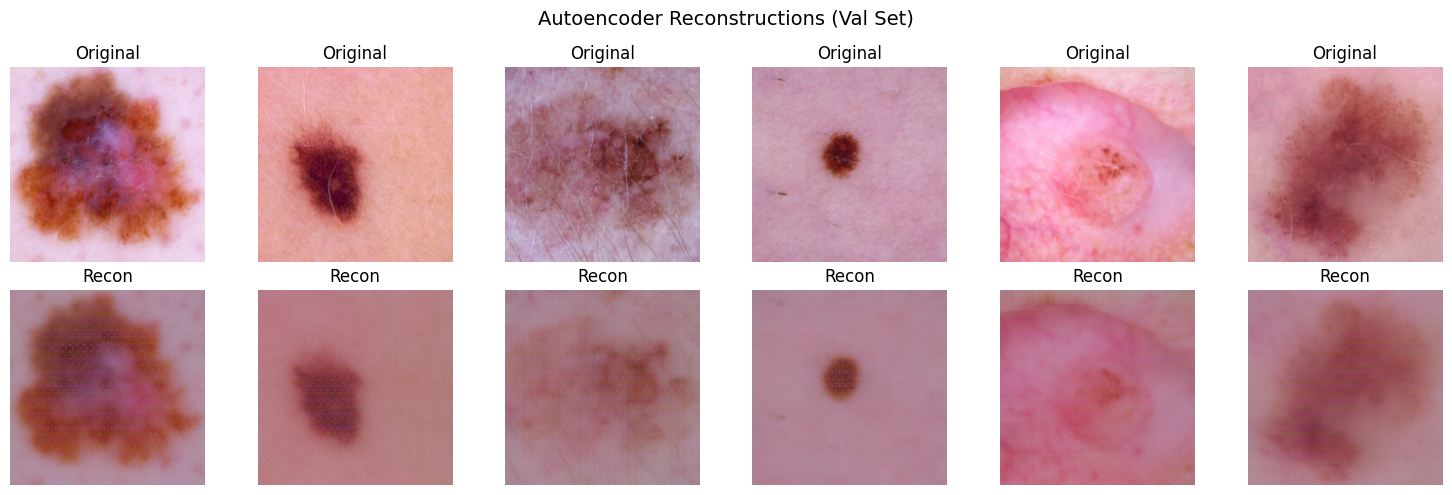

In [ ]:
# ── Visualize Reconstructions ─────────────────────────────────────────────────
model.eval()
sample_imgs, _ = next(iter(val_loader))
sample_imgs = sample_imgs[:6].to(DEVICE)

with torch.no_grad():
    reconstructed = model(sample_imgs)

# Move to CPU and unnormalize
sample_imgs = sample_imgs.cpu()
reconstructed = reconstructed.cpu()

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

sample_imgs = (sample_imgs * std + mean).clamp(0, 1)
reconstructed = (reconstructed * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(min(6, sample_imgs.size(0))):
    # Original
    ax = axes[0, i]
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title("Original")
    ax.axis("off")
    
    # Reconstructed
    ax = axes[1, i]
    rec_img = reconstructed[i].permute(1, 2, 0).numpy()
    ax.imshow(rec_img)
    ax.set_title("Recon")
    ax.axis("off")

plt.suptitle("Autoencoder Reconstructions (Val Set)", fontsize=14)
plt.tight_layout()
plt.show()